In [ ]:
import matplotlib.pyplot as plt
import mdtraj as md
import torch
from loguru import logger
from tqdm import tqdm

from planet_md import config

In [3]:
ATLAS_DATA_DIR = config.RAW_DATA_DIR / "atlas"
ATLAS_PROCESSED_DATA_DIR = config.PROCESSED_DATA_DIR / "atlas"

In [ ]:
from planet_md.data.atlas import ATLASDataModule

In [ ]:
adl = ATLASDataModule(
    ATLAS_PROCESSED_DATA_DIR / "atlas_processed.h5",
    seq_features=True,
    struct_features=True,
    batch_size=5,
    num_workers=0,
    train_pct=0.8,
    val_pct=0.1,
    random_seed=0,
    struct_stage="encoded",
)
adl.setup("train")
ads = adl.dataset

Fetching 22 files:   0%|          | 0/22 [00:00<?, ?it/s]

/home/ssledzieski/miniforge3/envs/rocketshp/lib/python3.11/site-packages/esm/pretrained.py:35: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(
/home/s

In [6]:
batch = [adl.dataset[0], adl.dataset[1], adl.dataset[2], adl.dataset[3]]

In [10]:
# fm = FlexibilityModel(1536, 1, 128, 8, 4)
# fm.train()

# loss_fn = torch.nn.MSELoss()

# losses = []
# optimizer = torch.optim.Adam(fm.parameters(), lr=1e-3)
# for epoch in range(1):
#     # logger.info(f"Epoch {epoch}")
#     for batch in tqdm(adl.train_dataloader(),leave=False):
#         (seq, struct), mask, y = batch
#         y_hat = fm((seq, struct))
#         loss = compute_masked_mse_loss(y_hat, y.unsqueeze(2), mask)
#         losses.append(loss.item())
#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()

In [ ]:
def load_checkpoint(chkpt):
    """
    PlanetMDModel(1536, 1, 128, 8, 4)
    """
    chk = torch.load(chkpt)
    hp = chk["hyper_parameters"]
    state_dict = {}
    fm = PlanetMDModel(
        hp["embedding_dim"],
        hp["output_dim"],
        hp["d_model"],
        hp["n_heads"],
        hp["n_layers"],
    )
    for k, v in chk["state_dict"].items():
        new_k = k.replace("child_model.", "")
        state_dict[new_k] = v
    fm.load_state_dict(state_dict)
    fm.eval()
    return fm

In [44]:
ckpt = torch.load(
    f"{os.environ.get("PLANET_MD_DIR", str(Path.home() / "PLANET-MD"))}/checkpoints/rmsf_full_04/model-epoch=16-train_loss=0.01.pt.ckpt"
)

/tmp/ipykernel_3885106/2199911354.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load("/mnt/home/ssledzieski/Projects/rocketshp/checkpoints/rmsf_full_04/mo

In [ ]:
ckpt["hyper_parameters"]

{'num_parameters': 16793601,
 'batch_size': 8,
 'lr': 0.001,
 'max_epochs': 20,
 'num_data_workers': 31,
 'shuffle': True,
 'precision': 'highest',
 'embedding_dim': 1536,
 'output_dim': 1,
 'd_model': 512,
 'n_heads': 8,
 'n_layers': 4}

: 

In [9]:
from dataclasses import dataclass

import omegaconf


@dataclass
class PARAMETERS:
    batch_size: int = 64
    lr: float = 0.007
    max_epochs: int = 20
    num_data_workers: int = 31
    shuffle: bool = True
    precision: str = "highest"
    num_parameters: int = 0


p = PARAMETERS()
config = omegaconf.OmegaConf.create(p)
newp = omegaconf.OmegaConf.load("../configs/config.yml")
config.update(newp)

In [10]:
len(adl.dataset), len(adl.train_data), len(adl.val_data), len(adl.test_data)

(4167, 3333, 414, 420)

In [11]:
SAMPLE_I = 5


def normalize(x):
    return (x - x.min()) / (x.max() - x.min())


f, rmsf = adl.train_data[SAMPLE_I]
key = adl.dataset.samples[adl.train_data.indices[SAMPLE_I]]
with torch.no_grad():
    yhat_both = fmnew([x.unsqueeze(0) for x in f]).squeeze()
    yhat_seqonly = fmnew(
        (f[0].unsqueeze(0), torch.zeros_like(f[1]).unsqueeze(0))
    ).squeeze()

bf_both = yhat_both.detach().cpu().numpy().squeeze()
bf_seqonly = yhat_seqonly.detach().cpu().numpy().squeeze()

plt.plot(rmsf, label="rmsf")
plt.plot(bf_both, label="predicted")
plt.plot(bf_seqonly, label="predicted seq only")
plt.legend()


from scipy.stats import pearsonr, spearmanr

spearman = spearmanr(rmsf, bf_both)
pearson = pearsonr(rmsf, bf_both)
mse = ((rmsf - bf_both) ** 2).mean()
logger.info(f"Protein: {key}")
logger.info(f"Spearman: {spearman}")
logger.info(f"Pearson: {pearson}")
logger.info(f"MSE: {mse}")

plt.show()

NameError: name 'fmnew' is not defined

In [13]:
pdb_code, rep = key.split("/")
traj = md.load_xtc(
    ATLAS_DATA_DIR / f"{pdb_code[:2]}/{pdb_code}_prod_{rep}_fit.xtc",
    top=ATLAS_DATA_DIR / f"{pdb_code[:2]}/{pdb_code}.pdb",
)

In [ ]:
from planet_md.trajectory import display_trajectory

view = display_trajectory(traj, bfactor=bf_both, coloring="bfactor", normalize=True)
view

NameError: name 'bf_both' is not defined

# RMSF Variance

In [4]:
import mdtraj as md

In [5]:
key = "5mdu_A/R2"
pdb_code, rep = key.split("/")
traj = md.load_xtc(
    ATLAS_DATA_DIR / f"{pdb_code[:2]}/{pdb_code}_prod_{rep}_fit.xtc",
    top=ATLAS_DATA_DIR / f"{pdb_code[:2]}/{pdb_code}.pdb",
)

print(ATLAS_DATA_DIR / f"{pdb_code[:2]}/{pdb_code}_prod_{rep}_fit.xtc")
print(ATLAS_DATA_DIR / f"{pdb_code[:2]}/{pdb_code}.pdb")

/mnt/home/ssledzieski/Projects/rocketshp/data/raw/atlas/5m/5mdu_A_prod_R2_fit.xtc
/mnt/home/ssledzieski/Projects/rocketshp/data/raw/atlas/5m/5mdu_A.pdb


In [6]:
traj

<mdtraj.Trajectory with 10001 frames, 2454 atoms, 157 residues, and unitcells at 0x7f1292e56cd0>

In [83]:
import numpy as np

subsample_rmsf = []
for _ in range(50):
    start = np.random.randint(0, traj.n_frames // 2)
    stride = np.random.randint(5, 50)
    t_sub = traj[start : start + traj.n_frames // 2 : stride]
    sample = md.rmsf(t_sub, t_sub, 0, atom_indices=traj.top.select("name CA"))
    subsample_rmsf.append(sample)

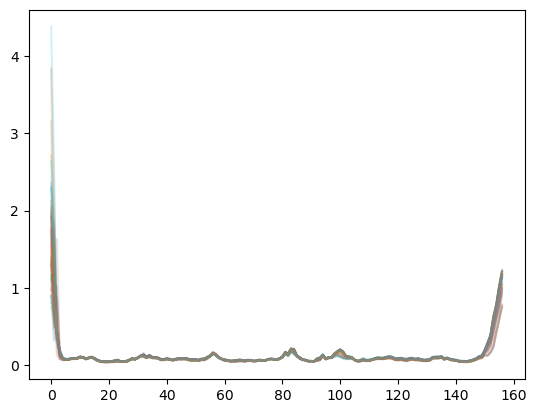

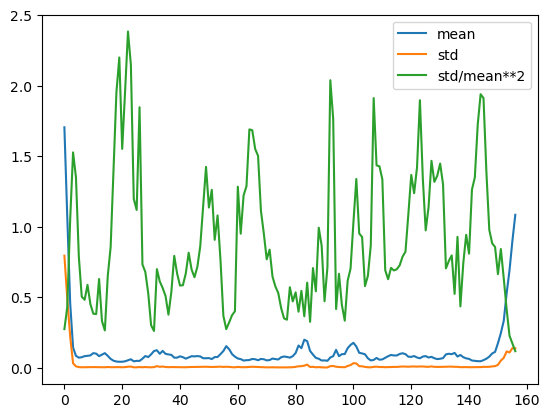

In [84]:
subsample_rmsf = np.stack(subsample_rmsf)
import matplotlib.pyplot as plt

plt.plot(np.arange(subsample_rmsf.shape[1]), subsample_rmsf.T, alpha=0.2)
plt.show()

plt.plot(np.arange(subsample_rmsf.shape[1]), subsample_rmsf.mean(axis=0), label="mean")
plt.plot(np.arange(subsample_rmsf.shape[1]), subsample_rmsf.std(axis=0), label="std")
plt.plot(
    np.arange(subsample_rmsf.shape[1]),
    subsample_rmsf.std(axis=0) / subsample_rmsf.mean(axis=0) ** 2,
    label="std/mean**2",
)
plt.legend()
plt.show()

# Time-Lagged Autocorrelation

In [26]:
from statsmodels.tsa.stattools import acf

In [14]:
import mdtraj as md
import numpy as np

# load sample trajectory
key = "5mdu_A/R2"
pdb_code, rep = key.split("/")
traj = md.load_xtc(
    ATLAS_DATA_DIR / f"{pdb_code[:2]}/{pdb_code}_prod_{rep}_fit.xtc",
    top=ATLAS_DATA_DIR / f"{pdb_code[:2]}/{pdb_code}.pdb",
)
# select ca only
traj = traj.atom_slice(traj.top.select("name CA"))

In [15]:
def position_autocorrelation(traj: md.Trajectory):
    pass


import numpy as np

In [16]:
from itertools import combinations


def compute_contacts(
    traj: md.Trajectory, scheme: str = "ca", ignore_nonprotein: bool = True
):
    return md.geometry.squareform(
        *md.compute_contacts(
            traj,
            contacts=list(combinations(np.arange(traj.n_residues), 2)),
            scheme=scheme,
            ignore_nonprotein=ignore_nonprotein,
        )
    )

In [17]:
def autocorrelate(X, tau):
    """
    X is (t, 1), where t is the number of time steps, and the remaining dimensions are a quantity that varies with time
    """
    x_shift_tau = X[tau:]
    x_numer = X[: len(x_shift_tau)] * x_shift_tau
    x_denom = X[: len(x_shift_tau)] * X[: len(x_shift_tau)]
    if (x_denom == 0).all():
        return 1
    c_tau = (x_numer / x_denom).mean()
    return c_tau

In [18]:
contacts = compute_contacts(traj)
res_0_1_dist = contacts[:, 0, 1]

In [ ]:
corrtime_matrix = np.eye(contacts.shape[1])
tau_matrix = np.eye(contacts.shape[1])
beta_matrix = np.eye(contacts.shape[1])


def correlation_time(acf, time_step=1.0):
    """Integrate the ACF until it first crosses zero"""
    # Find where ACF crosses zero
    zero_crossings = np.where(acf <= 0)[0]

    if len(zero_crossings) > 0:
        # Integrate until first zero crossing
        end_idx = zero_crossings[0]
        tau = np.sum(acf[:end_idx]) * time_step
    else:
        # If no zero crossing, use the whole array
        tau = np.sum(acf) * time_step

    return tau


from scipy.optimize import curve_fit


def fit_exponential_decay(acf, time_step=1.0):
    """Fit an exponential decay to extract the relaxation time"""

    def exp_decay(t, tau):
        return np.exp(-t / tau)

    def stretched_exp_decay(t, tau, beta):
        return np.exp(-((t / tau) ** beta))

    # Generate time values
    times = np.arange(len(acf)) * time_step

    # Perform fitting (focus on initial decay)
    # For multimodal decays, you might need to adjust this
    fit_length = min(
        len(acf), np.where(acf < 0.05)[0][0] if np.any(acf < 0.05) else len(acf)
    )

    try:
        popt, _ = curve_fit(
            exp_decay, times[:fit_length], acf[:fit_length], p0=[time_step * 10]
        )
        tau_e = popt[0]
        # beta_e = popt[1]
    except:
        # Fallback if fitting fails
        logger.warning("Fitting failed, using correlation time")
        tau_e = correlation_time(acf, time_step)
        beta_e = 1.0

    return tau_e  # , beta_e


for i, j in tqdm(
    combinations(range(contacts.shape[1]), 2),
    total=contacts.shape[1] * (contacts.shape[1] - 1) // 2,
):
    # Get time series
    # i = 0
    # j = 4
    res_i_j_dist = contacts[:, i, j]

    # Center the time series (fluctuations around mean)
    d_centered = res_i_j_dist - np.mean(res_i_j_dist)

    # Length of time series
    # n = len(d_centered)

    # # Variance (denominator for normalization)
    # variance = np.var(res_i_j_dist)

    # # Initialize autocorrelation array
    # acf_manual = np.zeros(len(traj) + 1)

    # for lag in range(len(traj) + 1):
    #     valid_len = n - lag
    #     acf_manual[lag] = np.sum(d_centered[:valid_len] * d_centered[lag:]) / (valid_len * variance)
    acf_statsmodels = acf(d_centered, nlags=len(traj), fft=True)

    # tau = correlation_time(acf_manual)
    ct = correlation_time(acf_statsmodels)
    tau_e = fit_exponential_decay(acf_statsmodels)

    # manual_tseries_corr[i, j] = tau
    corrtime_matrix[i, j] = ct
    tau_matrix[i, j] = tau_e
    # beta_matrix[i, j] = beta_e

# plt.plot(acf_manual, label="manual")
# plt.plot(acf_statsmodels, label="statsmodels")
# plt.axvline(tau, color="red", label=f"tau={tau:.2f}", linestyle="--")
# plt.axvline(tau_statsmodels, color="green", label=f"tau_statsmodels={tau_statsmodels:.2f}", linestyle="--")
# plt.legend()
# plt.show()

  0%|          | 0/12246 [00:00<?, ?it/s]/tmp/ipykernel_3679409/2286814129.py:38: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(exp_decay, times[:fit_length], acf[:fit_length], p0=[time_step*10])
100%|██████████| 12246/12246 [00:16<00:00, 728.50it/s]


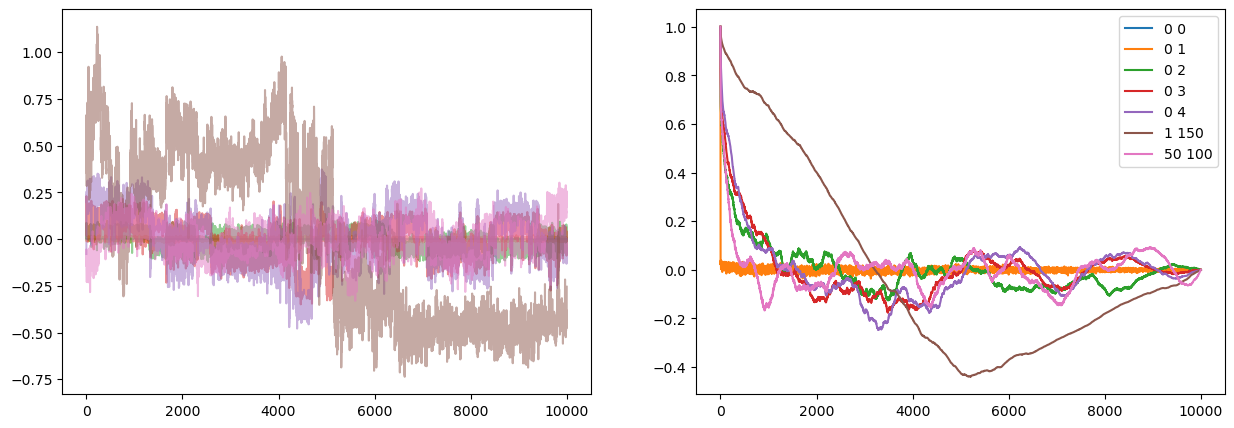

In [165]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))


def center(x):
    return x - x.mean()


ax[0].plot(center(contacts[:, 0, 0]), label="0 self", alpha=0.5)
ax[0].plot(center(contacts[:, 0, 1]), label="0 1", alpha=0.5)
ax[0].plot(center(contacts[:, 0, 2]), label="0 2", alpha=0.5)
ax[0].plot(center(contacts[:, 0, 3]), label="0 3", alpha=0.5)
ax[0].plot(center(contacts[:, 0, 4]), label="0 4", alpha=0.5)
ax[0].plot(center(contacts[:, 1, 150]), label="1 150", alpha=0.5)
ax[0].plot(center(contacts[:, 50, 100]), label="50 100", alpha=0.5)


def compute_and_plot_acf(contacts, i, j, ax):
    res_i_j_dist = contacts[:, i, j]

    # Center the time series (fluctuations around mean)
    d_centered = res_i_j_dist - np.mean(res_i_j_dist)
    acf_tmp = acf(d_centered, nlags=len(traj), fft=True)

    x = np.arange(len(acf_tmp))
    ax.plot(x, acf_tmp, label=f"{i} {j}")


compute_and_plot_acf(contacts, 0, 0, ax[1])
compute_and_plot_acf(contacts, 0, 1, ax[1])
compute_and_plot_acf(contacts, 0, 2, ax[1])
compute_and_plot_acf(contacts, 0, 3, ax[1])
compute_and_plot_acf(contacts, 0, 4, ax[1])
compute_and_plot_acf(contacts, 1, 150, ax[1])
compute_and_plot_acf(contacts, 50, 100, ax[1])

plt.legend()
plt.show()

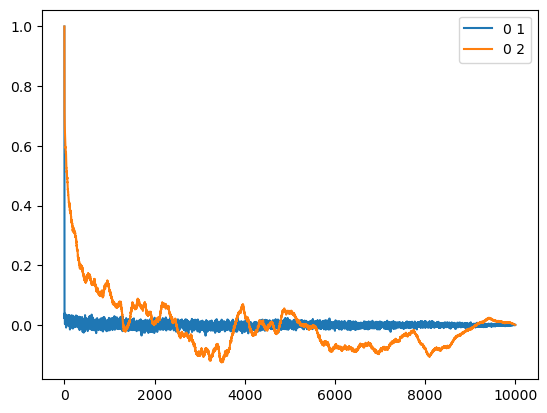

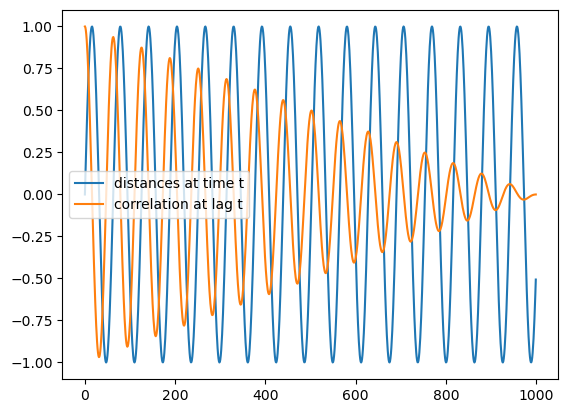

2025-03-17 15:14:43.989 | INFO     | __main__:<module>:9 - 14.736200239499093


In [152]:
# sin wave as test series
test_series = np.sin(10 * np.linspace(0, 10, 1000))
acf_test = acf(test_series, nlags=len(test_series), fft=True)
tau_test = fit_exponential_decay(acf_test)
plt.plot(test_series, label="distances at time t")
plt.plot(acf_test, label="correlation at lag t")
plt.legend()
plt.show()
logger.info(tau_test)

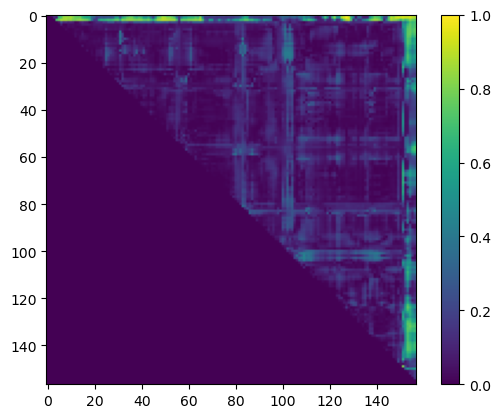

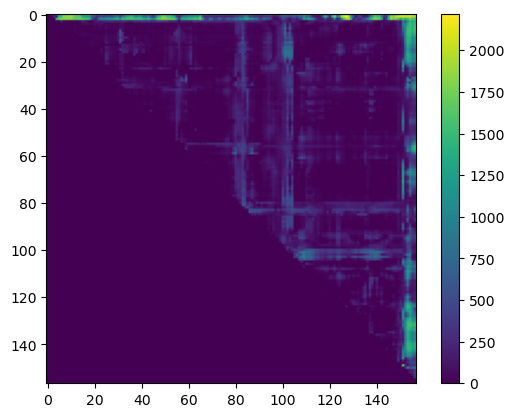

In [132]:
plt.imshow(corrtime_matrix / corrtime_matrix.max())
plt.colorbar()
plt.show()
plt.imshow(tau_matrix)
plt.colorbar()
plt.show()

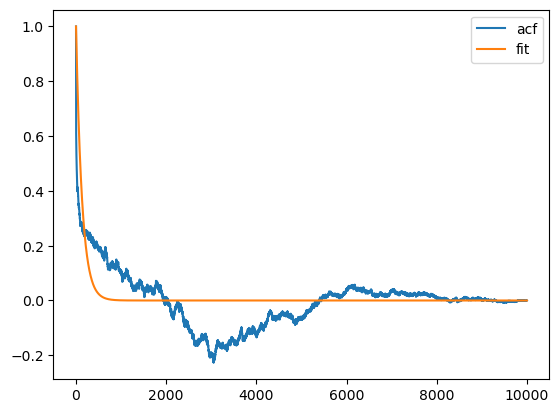

In [137]:
res_i_j_dist = contacts[:, 10, 150]

# Center the time series (fluctuations around mean)
d_centered = res_i_j_dist - np.mean(res_i_j_dist)
acf_tmp = acf(d_centered, nlags=len(traj), fft=True)


def exp_decay(t, tau):
    return np.exp(-t / tau)


x = np.arange(len(acf_tmp))
plt.plot(x, acf_tmp, label="acf")
popt, _ = curve_fit(exp_decay, x, acf_tmp, p0=[10])
plt.plot(x, exp_decay(x, *popt), label="fit")
plt.legend()
plt.show()

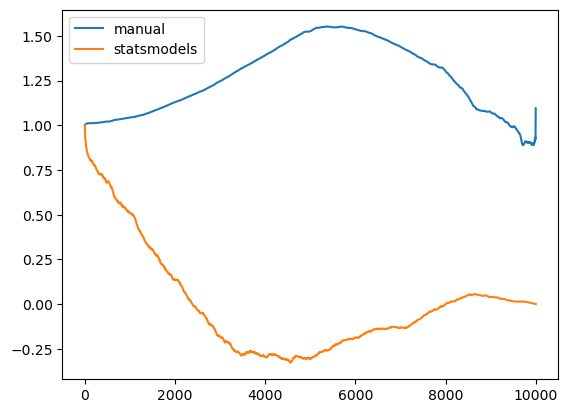

In [ ]:
i = 0
j = 5
res_i_j_dist = contacts[:, i, j]

acs = []
acf_list = acf(res_i_j_dist, nlags=contacts.shape[0] - 1, fft=True)
for tau in range(1, 10000):
    c_tau = autocorrelate(res_i_j_dist, tau)
    acs.append(c_tau)
plt.plot(acs, label="manual")
plt.plot(acf_list, label="statsmodels")
plt.legend()

In [21]:
autocorrelate(res_0_1_dist, tau)

1.0002474

In [ ]:
from scipy import stats


def mean_abs_autocorr(autocorrs):
    return np.mean(np.abs(autocorrs))


c_autos = np.eye(contacts.shape[1])
c_auto_means = np.zeros((contacts.shape[1], contacts.shape[1]))
# for c_other in tqdm(range(contacts.shape[1])):
for c_init, c_other in tqdm(combinations(range(contacts.shape[1]), 2)):
    # cts = []
    # for tau_max in range(contacts.shape[0]):
    #     c_tau = autocorrelate(contacts[:,1,c_other], tau_max)
    #     cts.append(c_tau)
    cts = acf(contacts[:, c_init, c_other], nlags=contacts.shape[0] - 1, fft=True)

    slope_0, intercept, r_value, p_value, std_err = stats.linregress(
        np.arange(cts.shape[0]), cts
    )
    c_autos[c_init, c_other] = slope_0
    c_autos[c_other, c_init] = slope_0
    c_auto_means[c_init, c_other] = mean_abs_autocorr(cts)
    c_auto_means[c_other, c_init] = mean_abs_autocorr(cts)

    # # Create figure and primary axis
    # fig, ax1 = plt.subplots()
    # line1 = ax1.plot(contacts[:,1,c_other], label="distance", color="lightgray")

    # ax2 = ax1.twinx()
    # ax2.plot(cts,label="autocorrelation")
    # # ax2.plot(-1.0 * , label="acf")
    # ax2.plot(np.arange(contacts.shape[0]) * slope_0 + intercept,label="linear fit")

    # plt.title(f"autocorrelation between res1 and res{c_other} (slope = {1e5*slope_0:.5f})")
    # plt.legend()
    # plt.show()

12246it [00:09, 1336.36it/s]


In [313]:
c_auto_means.min()

0.0

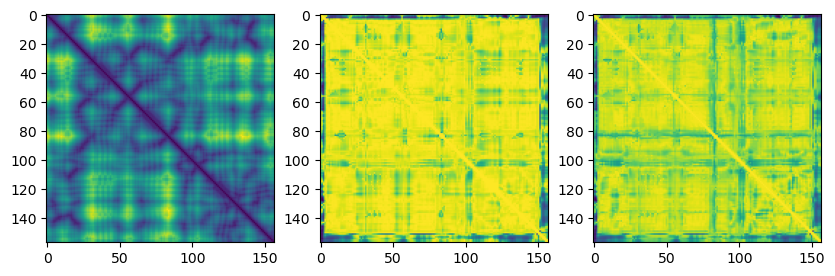

In [142]:
fig, ax = plt.subplots(1, 3, figsize=(10, 5))
ax[0].imshow(contacts[0])
ax[1].imshow(c_autos)
ax[2].imshow(-(c_auto_means))
plt.show()

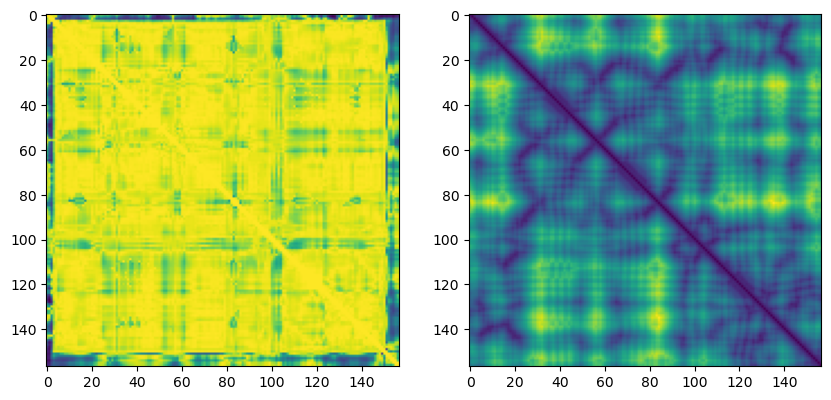

In [294]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(c_autos * 1e4)
ax[1].imshow(contacts[0])
plt.show()

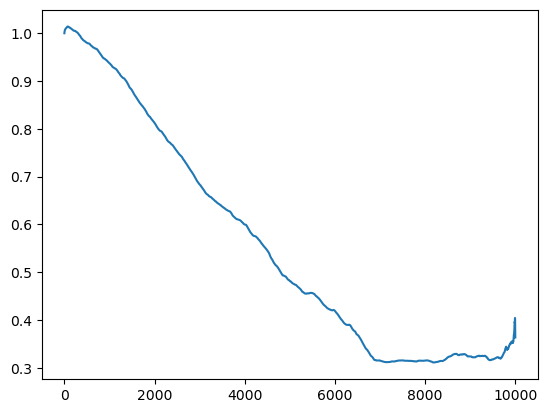

In [225]:
plt.plot(cts)

In [224]:
plt.plot(-1e4 * np.array(c_autos), label="autocorrelation")
plt.plot(contacts[0, 1, :], label="distance")
plt.legend()
plt.show()

SyntaxError: unmatched ')' (1161185746.py, line 1)

In [107]:
contacts.shape

(10001, 157, 157)

# Covariance Gaussian Network Model

In [35]:
from prody import GNM, parsePDB, showMode, showProtein

In [30]:
key = "5mdu_A/R2"
pdb_code, rep = key.split("/")
pdb_file = ATLAS_DATA_DIR / f"{pdb_code[:2]}/{pdb_code}.pdb"

In [31]:
prody_struct = parsePDB(str(pdb_file))

@> 2454 atoms and 1 coordinate set(s) were parsed in 0.12s.


In [32]:
calphas = prody_struct.select("calpha")

In [33]:
gnm = GNM(key)
gnm.buildKirchhoff(calphas, cutoff=7.0)
gnm.calcModes(n_modes=100)

@> Kirchhoff was built in 0.00s.
@> 100 modes were calculated in 0.01s.


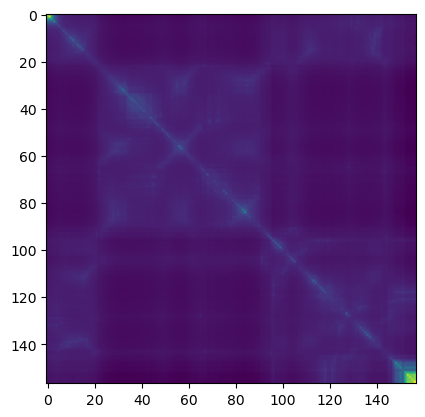

In [34]:
covar = gnm.getCovariance()
plt.imshow(covar)
plt.show()

([<matplotlib.lines.Line2D at 0x7ff3a7142b50>], [], [], [])

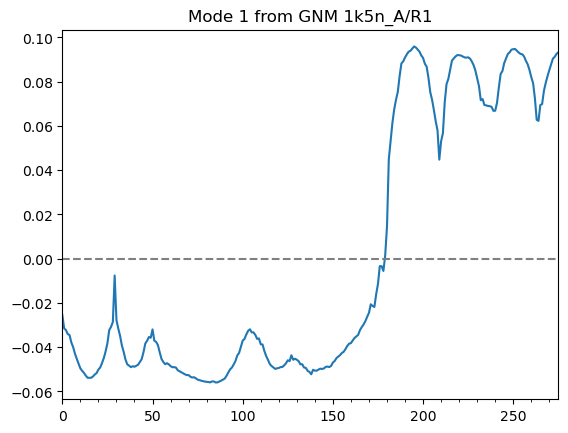

In [29]:
showMode(gnm[0])

<Axes3D: xlabel='x', ylabel='y', zlabel='z'>

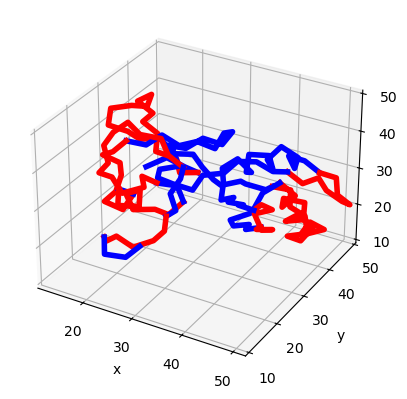

In [44]:
showProtein(calphas, mode=gnm[5])

# Cluster Trajectory KNN RMSD

In [112]:
import mdtraj as md
import numpy as np

# load sample trajectory
# key = "5mdu_A/R2"
key = "1k5n_A/R3"
pdb_code, rep = key.split("/")
traj = md.load_xtc(
    ATLAS_DATA_DIR / f"{pdb_code[:2]}/{pdb_code}_prod_{rep}_fit.xtc",
    top=ATLAS_DATA_DIR / f"{pdb_code[:2]}/{pdb_code}.pdb",
)
# select ca only
traj = traj.atom_slice(traj.top.select("name CA"))

In [113]:
traj_rmsd = md.rmsd(traj, traj, 0)

In [114]:
rmsd_all = np.zeros((traj.n_frames, traj.n_frames))
for i in tqdm(range(traj.n_frames)):
    rmsd_all[i] = md.rmsd(traj, traj, i)

100%|██████████| 10001/10001 [00:06<00:00, 1602.29it/s]


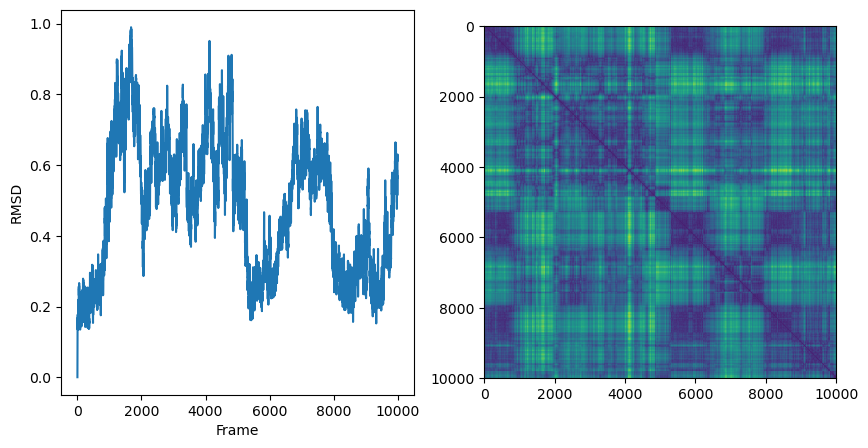

In [119]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].plot(rmsd_all[0, :])
ax[0].set_xlabel("Frame")
ax[0].set_ylabel("RMSD")
ax[1].imshow(rmsd_all)
plt.show()

clustering with k=2

 sil score: 0.4429042526026621
clustering with k=3 sil score: 0.4202459394205641
clustering with k=4 sil score: 0.3803102923720195
clustering with k=5 sil score: 0.35014395355438177


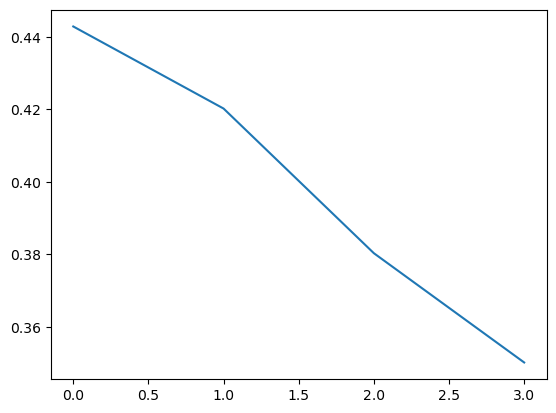

best k: 1


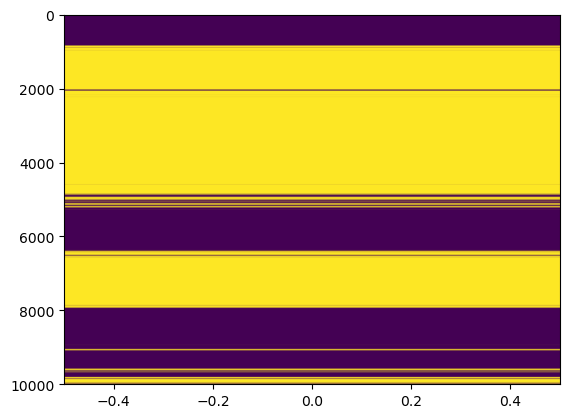

In [116]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# cluster frames with different values of k and evaluate silhouette_score, then select the best one and plot the clusters
sil_scores = []
kms = []
for k in range(2, 6):
    print(f"clustering with k={k}", end="")
    km = KMeans(n_clusters=k)
    km.fit(rmsd_all)
    kms.append(km)
    ss = silhouette_score(rmsd_all, km.labels_)
    print(f" sil score: {ss}")
    sil_scores.append(ss)
plt.plot(sil_scores)
plt.show()
km = kms[np.argmax(sil_scores)]
print(f"best k: {np.argmax(sil_scores) + 2}")
plt.imshow(km.labels_.reshape(-1, 1), aspect="auto")
plt.show()

In [86]:
rmsd_all.max()

0.5563317537307739

# MDSCAN -- Clustering Trajectories on RMSD

In [120]:
import mdtraj as md
import numpy as np

# load sample trajectory
# key = "5mdu_A/R3"
# key = "1k5n_A/R3"
# pdb_code, rep = key.split("/")
# traj = md.load_xtc(ATLAS_DATA_DIR / f"{pdb_code[:2]}/{pdb_code}_prod_{rep}_fit.xtc", top=ATLAS_DATA_DIR / f"{pdb_code[:2]}/{pdb_code}.pdb")
# select ca only
# traj = traj.atom_slice(traj.top.select("name CA"))

In [121]:
from mdscan import clusterize as clt
from mdscan import qmst

In [122]:
K = 5
N_SPLITS = 3
MIN_CLUSTER_SIZE = 3000
CLUST_SEL_MET = "eom"

# # ++++ Exhausting neighborhoods +++++++++++++++++++++++++++++++++++++++++
print("\n[1/4] Exhausting neighborhoods...")
Kd_arr, dist_arr, nn_arr, exhausted, D1 = qmst.exhaust_neighborhoods(traj, K, N_SPLITS)


# ++++ Joining exhausted nodes ++++++++++++++++++++++++++++++++++++++++++++
dist_arr, nn_arr, exh_ord = qmst.join_exhausted(
    exhausted, Kd_arr, dist_arr, nn_arr, traj
)
print("\n[2/4] Construction of the quasi-Minimum Spanning Tree completed.")

# ++++ Checks +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
# !!! to pass this check, you must set to -1 in nn_arr the argmin of dist_arr
# tree = qmst.check_tree(N1, nn_arr, dist_arr)
# cycl = nx.find_cycle(tree)
# connected = nx.is_connected(tree)
# network_exact = qmst.get_exact_MST(N1, traj, Kd_arr)
# mst_exact2 = qmst.get_prim_set(traj, Kd_arr)

# ======================================================================= #
# >>>> SECOND PART: CLUSTERS EXTRACTION                                   #
# ======================================================================= #
# ++++ Constructing the master topology of nodes ++++++++++++++++++++++++++
forest_top = clt.get_otree_topology2(nn_arr)

# ++++ Pruning the qMST +++++++++++++++++++++++++++++++++++++++++++++++++++
mcs = MIN_CLUSTER_SIZE
clusters, orig_clust_array = clt.prune_qMST2(nn_arr, dist_arr, forest_top, mcs)

# ++++ Assigning deltas and stabilities in a two-pass approach ++++++++++++
reclusters, ctree = clt.assign_deltas_and_stabilities2(clusters)
selected = [x for x in reclusters if reclusters[x]["delta"] == 1]

# ++++ Getting final clustering +++++++++++++++++++++++++++++++++++++++++++
final_array = clt.get_final_clusters(
    selected, reclusters, ctree, orig_clust_array, CLUST_SEL_MET, include_children=True
)


[1/4] Exhausting neighborhoods...


/mnt/home/ssledzieski/GitHub/MDScan/mdscan/vantage.py:92: RuntimeWarning: in rmsd(), precentered is ignored when atom_indices != None
  p_dists = md.rmsd(subtraj, subtraj, real_p, precentered=True)[real_indices]
/mnt/home/ssledzieski/GitHub/MDScan/mdscan/vantage.py:174: RuntimeWarning: in rmsd(), precentered is ignored when atom_indices != None
  vector = md.rmsd(self.traj, self.traj, point, precentered=True)
/mnt/home/ssledzieski/GitHub/MDScan/mdscan/qmst.py:219: RuntimeWarning: in rmsd(), precentered is ignored when atom_indices != None
  idx_rmsd = md.rmsd(traj, traj, idx, precentered=True)



[2/4] Construction of the quasi-Minimum Spanning Tree completed.


/mnt/home/ssledzieski/GitHub/MDScan/mdscan/clusterize.py:128: RuntimeWarning: divide by zero encountered in divide
  lamb = 1 / dist_arr


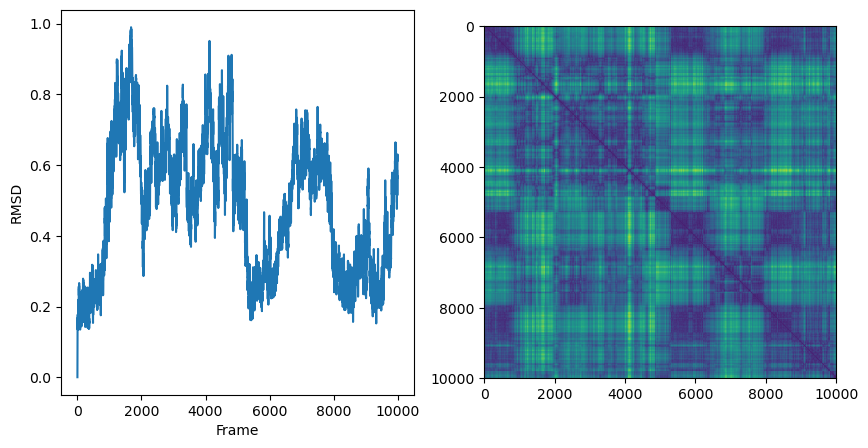

In [124]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].plot(rmsd_all[0, :])
ax[0].set_xlabel("Frame")
ax[0].set_ylabel("RMSD")
ax[1].imshow(rmsd_all)
plt.show()

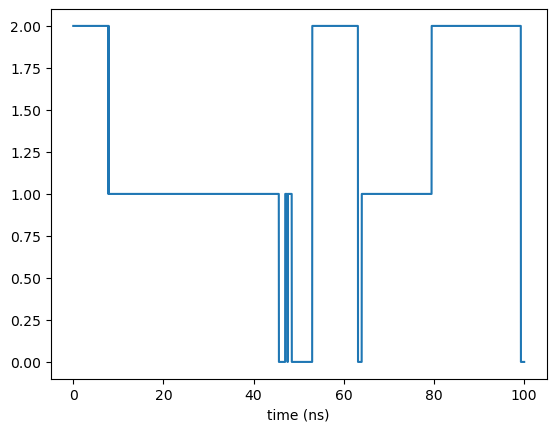

In [123]:
plt.plot(np.arange(0, 100.01, 0.01), orig_clust_array, label="o")
plt.xlabel("time (ns)")
plt.show()